# DELF-hm5C / hm5C Deep Ensemble Learning Framework Notebook

This notebook provides a simplified, GitHub-ready implementation of the deep-learning hm5C prediction pipeline. It covers the workflow from library imports and reproducibility settings to internal independent evaluation.

The main computational stages are:

1. import libraries and set random seeds;
2. define evaluation and plotting utilities;
3. define group-wise projection, attention pooling, and deep base learners;
4. load the encoded feature dataset;
5. split the data into training and internal independent test sets;
6. train/evaluate blending;
7. train/evaluate stacking using out-of-fold meta-features;
8. report internal independent test results and plots.

> **Note for users:** update the dataset/model paths before running this notebook outside the author’s Kaggle environment. The current version expects pre-extracted feature-vector CSV files rather than raw RNA sequences.

> **Note:** Results may vary slightly when this notebook is re-run because deep learning training can involve non-deterministic GPU operations, backend-level randomness, early stopping differences, and environment-specific floating-point computations.

In [ ]:
# -------------------------------------------------------------------
# Purpose: import all required libraries and fix random seeds for reproducibility.
# Update package versions in requirements.txt when preparing this notebook for GitHub users.
# -------------------------------------------------------------------
import os, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import numpy as np
import pandas as pd
import pickle
import joblib
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

%matplotlib inline

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, confusion_matrix, precision_score,
    log_loss, brier_score_loss, cohen_kappa_score, balanced_accuracy_score,
    auc, roc_curve, precision_recall_curve
)

from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import mcnemar

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


E0000 00:00:1782069739.268931      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782069739.323814      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782069739.767336      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782069739.767387      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782069739.767389      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782069739.767392      24 computation_placer.cc:177] computation placer already registered. Please check linka

## 1. Metrics and plotting utilities

This section defines helper functions used throughout the notebook. The functions calculate classification metrics, plot ROC and precision-recall curves, generate decision-curve analysis, summarize cross-validation metrics, and prepare fold-wise statistical comparison tables.

The central function is `compute_metrics()`, which receives true labels and predicted probabilities, selects a threshold using MCC, and returns the metrics needed for manuscript-style reporting.


In [2]:
# -------------------------------------------------------------------
# Purpose: define metric, curve-plotting, threshold-selection, and statistical helper functions.
# These functions are reused by blending, stacking, CV summaries, and internal-test reporting.
# -------------------------------------------------------------------
def plot_roc_curves(y_true, proba_dict, title="ROC Curves"):
    """
    proba_dict: {name: y_proba}
    """
    plt.figure(figsize=(6, 5))
    for name, y_proba in proba_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{title}_roc_auc.svg', dpi=300, bbox_inches='tight')
    plt.show()

def plot_pr_curves(y_true, proba_dict, title="PR Curves"):
    """
    proba_dict: {name: y_proba}
    """
    plt.figure(figsize=(6, 5))
    for name, y_proba in proba_dict.items():
        prec, rec, _ = precision_recall_curve(y_true, y_proba)
        ap = average_precision_score(y_true, y_proba)
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{title}_pr_auc.svg', dpi=300, bbox_inches='tight')
    plt.show()

def decision_curve(y_true, y_proba, thresholds=np.linspace(0.01, 0.99, 99)):
    """
    Decision Curve Analysis (Net Benefit).
    NetBenefit(t) = TP/N - FP/N * (t/(1-t))
    """
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).reshape(-1)
    N = len(y_true)

    nb = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        nb_t = (tp / N) - (fp / N) * (t / (1 - t))
        nb.append(nb_t)
    return thresholds, np.array(nb)

def plot_decision_curves(y_true, proba_dict, title="Decision Curve Analysis"):
    thresholds = np.linspace(0.01, 0.99, 99)
    plt.figure(figsize=(7, 5))

    # Treat-all and treat-none reference lines
    # treat-none net benefit = 0
    plt.plot(thresholds, np.zeros_like(thresholds), linestyle="--", label="Treat None")

    # treat-all net benefit depends on prevalence
    prev = np.mean(y_true)
    treat_all = prev - (1 - prev) * (thresholds / (1 - thresholds))
    plt.plot(thresholds, treat_all, linestyle="--", label="Treat All")

    for name, y_proba in proba_dict.items():
        t, nb = decision_curve(y_true, y_proba, thresholds=thresholds)
        plt.plot(t, nb, label=name)

    plt.xlabel("Threshold Probability")
    plt.ylabel("Net Benefit")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{title}_decision_curve.svg', dpi=300, bbox_inches='tight')
    plt.show()


def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.01, 0.99, 200)
    best_thr = 0.5
    best_mcc = -1

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        mcc = matthews_corrcoef(y_true, y_pred)
        if mcc > best_mcc:
            best_mcc = mcc
            best_thr = t

    return best_thr, best_mcc

def _safe_div(a, b):
    return float(a) / float(b) if b != 0 else 0.0

def compute_metrics(y_true, y_prob, thr=0.5):
    thr, _ = find_best_threshold(y_true, y_prob)
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    acc = accuracy_score(y_true, y_pred)
    sn = _safe_div(tp, tp + fn)
    sp = _safe_div(tn, tn + fp)
    prec = precision_score(y_true, y_pred, zero_division=0)
    npv = _safe_div(tn, tn + fn)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred) if len(np.unique(y_true)) == 2 else 0.0
    bacc = balanced_accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    gmean = float(np.sqrt(sn * sp))

    roc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan
    pr = average_precision_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan
    ll = log_loss(y_true, y_prob)#, eps=1e-7)
    brier = brier_score_loss(y_true, y_prob)

    return {
        "ACC": acc, "Sn": sn, "Sp": sp, "Precision": prec, "NPV": npv,
        "F1": f1, "MCC": mcc, "BACC": bacc, "Kappa": kappa, "G-Mean": gmean,
        "ROC-AUC": roc, "PR-AUC": pr, "LogLoss": ll, "Brier": brier,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
    }

def summarize_cv_metrics(list_of_metric_dicts):
    df = pd.DataFrame(list_of_metric_dicts)

    # convert everything possible to numeric
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    out = pd.DataFrame({
        "mean": df.mean(numeric_only=True),
        "std":  df.std(numeric_only=True, ddof=1)  # needs >=2 values
    })
    return out

# ----------------------------
# helpers
# ----------------------------
def mean_sd_str(values, ndigits=3):
    values = np.asarray(values, dtype=float)
    return f"{values.mean():.{ndigits}f} ± {values.std(ddof=1):.{ndigits}f}"

def format_p(p):
    # format like "3.2 × 10⁻³" or decimal if not tiny
    if p is None:
        return "–"
    if p == 0:
        return "< 1 × 10⁻⁶"
    if p < 0.001:
        exp = int(np.floor(np.log10(p)))
        mant = p / (10**exp)
        return f"{mant:.1f} × 10^{exp}"
    return f"{p:.4f}"

def mcnemar_bc(y_true, ref_pred, cmp_pred):
    y_true = np.asarray(y_true).astype(int)
    ref_pred = np.asarray(ref_pred).astype(int)
    cmp_pred = np.asarray(cmp_pred).astype(int)

    b = int(np.sum((ref_pred == y_true) & (cmp_pred != y_true)))
    c = int(np.sum((ref_pred != y_true) & (cmp_pred == y_true)))
    n = b + c

    # McNemar exact p-value (recommended for moderate n)
    if n == 0:
        p = 1.0
    else:
        res = mcnemar([[0, b], [c, 0]], exact=True)
        p = float(res.pvalue)
    return b, c, n, p


# ----------------------------
# MAIN: build table
# ----------------------------
def build_mcnemar_table(
    fold_metric_dicts,                # your dict: model -> list of metric dicts (one per fold)
    preds_dir="stack_fold_preds",     # folder containing oof_preds_{model}.npy and y_train.npy
    reference="CNN",                  # reference model for b,c,n,p
    models_order=None,                # list of models in desired table order
    ndigits_metrics=3                 # decimals for mean±sd
):
    y_true = np.load("y_train.npy") # np.load(os.path.join(preds_dir, "y_train.npy"))

    # decide model order
    if models_order is None:
        models_order = [m for m in fold_metric_dicts.keys()]

    rows = []

    # load reference oof preds
    ref_path = os.path.join(preds_dir, f"oof_preds_{reference}.npy")
    ref_pred = np.load(ref_path)

    for model in models_order:
        # mean±sd metrics from fold_metric_dicts
        mets = fold_metric_dicts[model]
        acc = mean_sd_str([d["ACC"] for d in mets], ndigits=ndigits_metrics)
        f1  = mean_sd_str([d["F1"]  for d in mets], ndigits=ndigits_metrics)
        mcc = mean_sd_str([d["MCC"] for d in mets], ndigits=ndigits_metrics)

        if model == reference:
            rows.append({
                "Model": model,
                "ACC (mean ± s.d.)": acc,
                "F1 (mean ± s.d.)": f1,
                "MCC (mean ± s.d.)": mcc,
                "b": "–", "c": "–", "n": "–", "p-values": "–"
            })
            continue

        # load competitor oof preds
        cmp_path = os.path.join(preds_dir, f"oof_preds_{model}.npy")
        cmp_pred = np.load(cmp_path)

        b, c, n, p = mcnemar_bc(y_true, ref_pred, cmp_pred)

        rows.append({
            "Model": model,
            "ACC (mean ± s.d.)": acc,
            "F1 (mean ± s.d.)": f1,
            "MCC (mean ± s.d.)": mcc,
            "b": b, "c": c, "n": n,
            "p-values": format_p(p)
        })

    return pd.DataFrame(rows)

# ==============================
# ROC Curve with 95% CI
# ==============================
def plot_mean_roc(models, title="Mean ROC-AUC (5-fold CV) with 95% CI"):
    plt.figure(figsize=(7,5))
    plt.plot([0,1],[0,1],'--')

    for model in models:
        scores = np.load(os.path.join(preds_dir, f"oof_prob_{model}.npy"))

        fpr_grid = np.linspace(0,1,300)
        tprs = []
        aucs = []

        for _, va in fold_indices:
            y_fold = y_true[va]
            s_fold = scores[va]

            fpr, tpr, _ = roc_curve(y_fold, s_fold)
            aucs.append(auc(fpr, tpr))

            tpr_interp = np.interp(fpr_grid, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)

        tprs = np.vstack(tprs)
        mean_tpr = tprs.mean(axis=0)
        std_tpr  = tprs.std(axis=0, ddof=1)

        lo = np.clip(mean_tpr - 1.96*std_tpr, 0, 1)
        hi = np.clip(mean_tpr + 1.96*std_tpr, 0, 1)

        plt.plot(fpr_grid, mean_tpr,
                 label=f"{model} (AUC={np.mean(aucs):.3f})")
        plt.fill_between(fpr_grid, lo, hi, alpha=0.15)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Mean ROC-AUC (5-fold CV) with 95% CI")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(f"{title}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{title}.svg", dpi=300, bbox_inches="tight")
    plt.show()


def plot_mean_pr_fixed(models, 
                       title="Mean PR-Curve (k-fold) with 95% CI", n_grid=400):

    recall_grid = np.linspace(0, 1, n_grid)

    plt.figure(figsize=(7, 5))

    for model in models:
        scores = np.load(os.path.join(preds_dir, f"oof_prob_{model}.npy")).astype(float).ravel()

        prec_mat = []
        ap_list = []

        for _, va in fold_indices:
            y_va = y_true[va]
            s_va = scores[va]

            prec, rec, _ = precision_recall_curve(y_va, s_va)
            ap_list.append(average_precision_score(y_va, s_va))

            # IMPORTANT: sklearn returns rec in decreasing order -> reverse to increasing
            rec_inc = rec[::-1]
            prec_inc = prec[::-1]

            # ensure strictly increasing recall for interpolation (remove duplicates if any)
            rec_unique, idx = np.unique(rec_inc, return_index=True)
            prec_unique = prec_inc[idx]

            # interpolate precision onto a common recall grid
            prec_interp = np.interp(recall_grid, rec_unique, prec_unique)
            prec_mat.append(prec_interp)

        prec_mat = np.vstack(prec_mat)

        prec_mean = prec_mat.mean(axis=0)
        prec_std  = prec_mat.std(axis=0, ddof=1)

        lo = np.clip(prec_mean - 1.96 * prec_std, 0, 1)
        hi = np.clip(prec_mean + 1.96 * prec_std, 0, 1)

        plt.plot(recall_grid, prec_mean, label=f"{model} (AP={np.mean(ap_list):.3f})")
        plt.fill_between(recall_grid, lo, hi, alpha=0.15)

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Mean PR-Curve (k-fold) with 95% CI")
    plt.grid(True, alpha=0.2)
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig(f"{title}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{title}.svg", dpi=300, bbox_inches="tight")
    plt.show()


# ==============================
# Violin Plot of Fold ROC-AUC
# ==============================
def plot_violin_auc(models, title="Fold-wise ROC-AUC Distribution"):
    auc_lists = []

    for model in models:
        scores = np.load(os.path.join(preds_dir, f"oof_prob_{model}.npy"))
        aucs = []

        for _, va in fold_indices:
            y_fold = y_true[va]
            s_fold = scores[va]
            fpr, tpr, _ = roc_curve(y_fold, s_fold)
            aucs.append(auc(fpr, tpr))

        auc_lists.append(aucs)

    plt.figure(figsize=(7,5))
    plt.violinplot(auc_lists, showmeans=False, showmedians=False)

    means = [np.mean(a) for a in auc_lists]
    x = np.arange(1,len(models)+1)
    plt.scatter(x, means, marker="_", s=300)

    plt.xticks(x, models, rotation=30)
    plt.ylabel("ROC-AUC")
    plt.title("Fold-wise ROC-AUC Distribution")
    plt.grid(True, axis='y', alpha=0.2)
    plt.tight_layout()
    plt.savefig(f"{title}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{title}.svg", dpi=300, bbox_inches="tight")
    plt.show()


## 2. Deep model components and training helper

This section defines the neural-network building blocks used by all base learners. The feature vector is first divided into descriptor groups, each group is projected into a shared latent space, and the resulting sequence-like tensor is passed into CNN, GRU, LSTM, or DNN branches.

`AttentionPooling1D` learns how much each projected feature region contributes to the final binary decision. `train_one_dl()` handles model training with early stopping and checkpoint saving.


In [3]:
# -------------------------------------------------------------------
# Purpose: define the attention-pooling layer and group-wise projection block.
# Each feature group is projected separately before all groups are concatenated.
# -------------------------------------------------------------------
### ---- Attention Pooling ----
@tf.keras.utils.register_keras_serializable()
class AttentionPooling1D(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        H = input_shape[-1]
        self.w = self.add_weight(shape=(H, 1), initializer="glorot_uniform", name="w", trainable=True)
        self.b = self.add_weight(shape=(1,), initializer="zeros", name="b", trainable=True)

    def call(self, x):
        scores = tf.matmul(x, self.w) + self.b
        weights = tf.nn.softmax(scores, axis=1)
        return tf.reduce_sum(x * weights, axis=1)

    def get_config(self):
        return super().get_config()

# ---- Group-wise Projection ----
def group_wise_projection(group_order, group_sizes, group_dmodels=None, shared_d_model=64):
    if group_dmodels is None:
        group_dmodels = {g: (16 if g == "PSTNPV" else 32) for g in group_order}

    inputs, aligned = [], []
    for g in group_order:
        Lg, dg = group_sizes[g], group_dmodels[g]
        inp = layers.Input(shape=(Lg, 1), name=f"{g}_in")
        x = layers.Dense(dg, name=f"{g}_proj")(inp)
        x = layers.Dense(shared_d_model, name=f"{g}_to_shared")(x)
        inputs.append(inp)
        aligned.append(x)

    x = layers.Concatenate(axis=1, name="concat_time")(aligned)  # (N, sum(Lg), shared_d_model)
    return inputs, x

class PrintOnlyImprovements(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.best_val_acc = 0.0
        self.best_val_loss = float('inf')
        self.keys_checked = False

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        
        # Determine the correct keys (Keras names them differently sometimes)
        val_acc = logs.get('val_accuracy') or logs.get('val_acc')
        val_loss = logs.get('val_loss')

        improved = []

        # Check Loss (Lower is better)
        if val_loss is not None and val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            improved.append(f"Loss: {val_loss:.4f}")

        # Check Accuracy (Higher is better)
        if val_acc is not None and val_acc > self.best_val_acc:
            self.best_val_acc = val_acc
            improved.append(f"Acc: {val_acc:.4f}")

        # Only print if at least one metric improved
        if improved:
            print(f"Epoch {epoch+1}: {' | '.join(improved)}")


In [4]:
# -------------------------------------------------------------------
# Purpose: define CNN, GRU, LSTM, and DNN base learners plus the training helper.
# All models receive the same grouped FFV inputs and output one sigmoid probability.
# -------------------------------------------------------------------
# ---- Model builders ----
l2_rate = 2.577397577975361e-05
lr_rate = 0.0005

def build_cnn(group_order, group_sizes, l2_reg=l2_rate, lr=lr_rate):
    inputs, x = group_wise_projection(group_order, group_sizes)
    x = layers.Conv1D(filters=24, kernel_size=2, strides=1,          
        padding='same', activation="relu", kernel_regularizer=l2(l2_reg))(x)

    x = layers.Dropout(0.3)(x)
    x = layers.LayerNormalization()(x)
    x = AttentionPooling1D(name="attn_pool")(x)

    out = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inputs, out, name="CNN_PosAtt")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

def build_gru(group_order, group_sizes, l2_reg=l2_rate, lr=lr_rate):
    inputs, x = group_wise_projection(group_order, group_sizes)

    x = layers.GRU(32, return_sequences=True, dropout=0.2,
                                        kernel_regularizer=l2(l2_reg))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LayerNormalization()(x)
    
    x = AttentionPooling1D(name="attn_pool")(x)

    out = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inputs, out, name="BiGRU_PosAtt")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

def build_lstm(group_order, group_sizes, l2_reg=l2_rate, lr=lr_rate):
    inputs, x = group_wise_projection(group_order, group_sizes)

    x = layers.LSTM(64, return_sequences=True, dropout=0.2,
                                        kernel_regularizer=l2(l2_reg))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LayerNormalization()(x)
    
    x = AttentionPooling1D(name="attn_pool")(x)

    out = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inputs, out, name="BiGRU_PosAtt")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

def build_dnn(group_order, group_sizes, l2_reg=l2_rate, lr=lr_rate):
    inputs, x = group_wise_projection(group_order, group_sizes)
    x = layers.Dense(64, kernel_regularizer=l2(l2_reg))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LayerNormalization()(x)
    
    x = AttentionPooling1D(name="attn_pool")(x)
    
    out = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inputs, out, name="DNN_PosAtt")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

DL_BUILDERS = {"CNN": build_cnn, "GRU": build_gru, "LSTM": build_lstm, "DNN": build_dnn}

def train_one_dl(model, X_tr, y_tr, X_val, y_val, run_name, epochs=1500, batch_size=32):
    cbs = [PrintOnlyImprovements(),
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=70, mode='max', restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(f"{run_name}.keras", save_best_only=True, monitor="val_accuracy")
    ]


    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=cbs,
    )


## 3. Load the encoded feature dataset

The notebook expects a CSV file containing the already extracted feature vectors and a binary label column. The label column should be named `label`; if your dataset uses another column name, update `LABEL_COL`.

The `name` column is removed from the feature matrix because it is an identifier, not a predictive feature.


In [5]:
# -------------------------------------------------------------------
# Purpose: load the main encoded hm5C feature-vector dataset and separate X/y.
# Change CSV_PATH when running in another Kaggle dataset, local folder, or GitHub setup.
# -------------------------------------------------------------------
CSV_PATH = "/kaggle/input/datasets/muhammadattique/hm5c-benchmark-independent-260212/main_dataset_fvs.csv"

df_main = pd.read_csv(CSV_PATH)

LABEL_COL = "label"   # <-- change if needed

assert LABEL_COL in df_main.columns, f"{LABEL_COL} not found in main dataset"

y_main = df_main[LABEL_COL].astype(int).reset_index(drop=True)
X_main_df = df_main.drop(columns=[LABEL_COL,"name"]).reset_index(drop=True)

print("X_main:", X_main_df.shape, "y_main:", y_main.shape)


X_main: (1324, 561) y_main: (1324,)


## 4. Define feature groups and preprocessing helpers

The final feature vector is organized into descriptor groups: `SEQMAT`, `LRIM`, `ILRIM`, `NoDV`, `APRIV`, `IAPRIV`, and `PSTNPV`.

These helper functions identify group-specific columns, fit median imputation and MinMax scaling, transform feature frames, and convert flat feature matrices into grouped tensors suitable for the multi-input Keras models.


In [6]:
# -------------------------------------------------------------------
# Purpose: locate descriptor-specific feature columns and prepare preprocessing utilities.
# The grouped inputs are required because each model is built with one input per descriptor group.
# -------------------------------------------------------------------
GROUP_ORDER = ['SEQMAT','LRIM','ILRIM','NoDV','APRIV','IAPRIV','PSTNPV']

assert 'GROUP_ORDER' in globals(), "Define GROUP_ORDER first."

def split_groups_from_df(X: pd.DataFrame, group_order):
    groups, sizes = {}, {}
    for g in group_order:
        cols = [c for c in X.columns if c.startswith(g + '_') or c == g]
        if len(cols) == 0:
            raise ValueError(f"No columns found for group prefix: {g}")
        groups[g] = cols
        sizes[g] = len(cols)
    return groups, sizes

GROUP_COLS, GROUP_SIZES = split_groups_from_df(X_main_df, GROUP_ORDER)
# print("Group sizes:", GROUP_SIZES)

def fit_preprocessers(X_train_df):
    imputer = SimpleImputer(strategy="median")
    scaler = MinMaxScaler()
    X_imp = imputer.fit_transform(X_train_df.values)
    X_scl = scaler.fit_transform(X_imp)
    return imputer, scaler

def transform_df(X_df_part, imputer, scaler):
    X_imp = imputer.transform(X_df_part.values)
    X_scl = scaler.transform(X_imp)
    return pd.DataFrame(X_scl, columns=X_df_part.columns, index=X_df_part.index)

def df_to_group_inputs(X_scaled_df: pd.DataFrame, group_cols: dict, group_order: list):
    X_list = []
    for g in group_order:
        arr = X_scaled_df[group_cols[g]].values.astype("float32")
        arr = arr[..., None]  # (N,L)->(N,L,1)
        X_list.append(arr)
    return X_list


## 5. Create training and internal independent test splits

The main dataset is split into a training set and an internal holdout test set. Stratification preserves the positive/negative class balance.

The internal test set is kept unseen during model training, blending, stacking, and model selection, so it can be used for unbiased final evaluation.


In [7]:
# -------------------------------------------------------------------
# Purpose: create a stratified train/internal-test split from the benchmark dataset.
# The internal test set remains unseen during training and meta-learner construction.
# -------------------------------------------------------------------
# Internal holdout test from MAIN only
train_idx, test_idx = train_test_split(
    np.arange(len(y_main)),
    test_size=133/1324,
    stratify=y_main,
    random_state=SEED
)

X_train_df = X_main_df.iloc[train_idx].reset_index(drop=True)
y_train    = y_main.iloc[train_idx].reset_index(drop=True)

X_test_df  = X_main_df.iloc[test_idx].reset_index(drop=True)   # internal test
y_test     = y_main.iloc[test_idx].reset_index(drop=True)

print("Train:", X_train_df.shape, "Internal test:", X_test_df.shape)


Train: (1191, 561) Internal test: (133, 561)


## 6. Blending phase

Blending uses a separate subset of the training data to train the meta-learner. The base learners are trained on the base subset. Their probability outputs on the blend subset become meta-features for Logistic Regression.

The internal independent test set is transformed using the same preprocessing fitted on the base subset, then used only for final evaluation.


In [8]:
# -------------------------------------------------------------------
# Purpose: split the training data into base-training and blend subsets.
# Base learners train on X_base/y_base; Logistic Regression meta-learner trains on X_blend predictions.
# -------------------------------------------------------------------
base_idx, blend_idx = train_test_split(
    np.arange(len(y_train)), test_size=0.2, stratify=y_train, random_state=SEED
)

X_base_df  = X_train_df.iloc[base_idx].reset_index(drop=True)
y_base     = y_train.iloc[base_idx].reset_index(drop=True)

X_blend_df = X_train_df.iloc[blend_idx].reset_index(drop=True)
y_blend    = y_train.iloc[blend_idx].reset_index(drop=True)

print("Base:", X_base_df.shape, "Blend:", X_blend_df.shape)


Base: (952, 561) Blend: (239, 561)


### 6.1 Fit preprocessing for blending

The imputer and scaler are fitted only on the base-training subset. This is important because fitting preprocessing on blend or test data would introduce information leakage.

After fitting, the base, blend, and internal test feature matrices are transformed and converted into grouped model inputs.


In [9]:
# -------------------------------------------------------------------
# Purpose: fit preprocessing on the base subset only and transform base/blend/internal data.
# This avoids data leakage from the blend or internal independent test set.
# -------------------------------------------------------------------
# Fit preprocess on BASE ONLY (important!)
imputer, scaler = fit_preprocessers(X_base_df)

X_base_scaled  = transform_df(X_base_df,  imputer, scaler)
X_blend_scaled = transform_df(X_blend_df, imputer, scaler)

X_test_scaled  = transform_df(X_test_df,  imputer, scaler)       # internal test

# DL inputs (grouped)
X_base_dl  = df_to_group_inputs(X_base_scaled,  GROUP_COLS, GROUP_ORDER)
X_blend_dl = df_to_group_inputs(X_blend_scaled, GROUP_COLS, GROUP_ORDER)

X_test_dl  = df_to_group_inputs(X_test_scaled,  GROUP_COLS, GROUP_ORDER)

# TAB inputs (flatten)
X_base_tab  = X_base_scaled.values.astype("float32")
X_blend_tab = X_blend_scaled.values.astype("float32")

X_test_tab  = X_test_scaled.values.astype("float32")


### 6.2 Prepare blending containers and early-stopping split

This cell creates prediction containers for the base learners and blending ensemble. It also creates a small validation subset from the base split for deep-learning early stopping.

The `get_predictions()` wrapper is used for TensorFlow inference. If retracing warnings appear during repeated model calls, they usually do not affect correctness; `model.predict(..., batch_size=256)` can also be used for simpler inference.


In [10]:
# -------------------------------------------------------------------
# Purpose: initialize prediction containers and create an internal validation split for early stopping.
# The same fitted imputer/scaler from the base subset is used here.
# -------------------------------------------------------------------
@tf.function(reduce_retracing=True)
def get_predictions(model, data):
    return model(data, training=False)
    
blend_dir = "blend_pretrained"
os.makedirs(blend_dir, exist_ok=True)

# Internal val for DL early stopping
tr2_idx, val2_idx = train_test_split(
    np.arange(len(y_base)), test_size=0.1, stratify=y_base, random_state=SEED
)

X_tr2_df, X_val2_df = X_base_df.iloc[tr2_idx], X_base_df.iloc[val2_idx]
y_tr2, y_val2 = y_base.iloc[tr2_idx].reset_index(drop=True), y_base.iloc[val2_idx].reset_index(drop=True)

X_tr2_scaled = transform_df(X_tr2_df, imputer, scaler)
X_val2_scaled = transform_df(X_val2_df, imputer, scaler)
X_tr2_dl = df_to_group_inputs(X_tr2_scaled, GROUP_COLS, GROUP_ORDER)
X_val2_dl = df_to_group_inputs(X_val2_scaled, GROUP_COLS, GROUP_ORDER)

base_learner_names = list(DL_BUILDERS.keys())

# For meta-learner training (blend set)
blend_pred_cols = []

# For evaluation (internal)
test_pred_cols_int = []

test_metrics_int = {}

# Store probabilities for plots (base learners + blending)
proba_int = {}   # internal test probs


### 6.3 Option A: train blending base learners from scratch

Use this cell when you want to retrain CNN, GRU, LSTM, and DNN base learners. It is currently commented out to avoid long execution time.

Uncomment this cell only when training from scratch is required. It will train each base learner, save its weights, generate blend-set predictions, and generate internal-test predictions.


In [11]:
# -------------------------------------------------------------------
# Optional training block: uncomment to train blending base learners from scratch.
# Keep commented when using pre-trained models to reduce execution time.
# -------------------------------------------------------------------
# # ---- DL learners ----
# for name, builder in DL_BUILDERS.items():
#     print("Training DL (blend):", name)
#     m = builder(GROUP_ORDER, GROUP_SIZES)
#     train_one_dl(m, X_tr2_dl, y_tr2, X_val2_dl, y_val2,run_name=f"blend_base_{name}", epochs=1500)

#     m.save_weights(os.path.join(blend_dir, f"{name}.weights.h5")) #<---- Change the path accordingly

#     p_blend = m.predict(X_blend_dl, batch_size=256, verbose=0).ravel()
#     p_int   = m.predict(X_test_dl,  batch_size=256, verbose=0).ravel()

#     proba_int[name] = p_int

#     blend_pred_cols.append(p_blend)
#     test_pred_cols_int.append(p_int)

#     test_metrics_int[name] = compute_metrics(y_test, p_int)
#     # CRITICAL: Reset graph counters and free up GPU memory leaks
#     tf.keras.backend.clear_session()

# blend_metaX = np.vstack(blend_pred_cols).T
# test_metaX_int = np.vstack(test_pred_cols_int).T

# print("Blend metaX:", blend_metaX.shape, "Internal test metaX:", test_metaX_int.shape)

# # Meta-learner (blending)
# meta_blend = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED)
# meta_blend.fit(blend_metaX, y_blend.values)

# p_blend_int = meta_blend.predict_proba(test_metaX_int)[:, 1]

# proba_int["Blending"] = p_blend_int

# blend_ensemble_metrics_int = compute_metrics(y_test, p_blend_int)

# # ---- Build metrics table (Internal / External) for base learners + Blending ----
# rows_int = {name: compute_metrics(y_test, prob) for name, prob in proba_int.items()}

# table_int = pd.DataFrame(rows_int).T

# print("Blending (Internal):", {k: round(v,4) for k,v in blend_ensemble_metrics_int.items() if k in ["ACC","MCC","ROC-AUC","PR-AUC","F1"]})


### 6.4 Option B: load already trained blending base learners

This is the faster execution option. It reloads previously trained `.keras` models, saves their weights into `blend_pretrained`, generates blend-set meta-features, and evaluates base learners on the internal independent test set.

Update the model path before running this notebook in a new Kaggle account, local machine, or GitHub/Hugging Face environment.


In [12]:
# -------------------------------------------------------------------
# Purpose: load pre-trained base learners, generate blending meta-features, and train the blending meta-learner.
# Update the load_model path before sharing/executing this notebook in a different environment.
# -------------------------------------------------------------------
# ---- DL learners ----
for name, builder in DL_BUILDERS.items():
    print("Training DL (blend):", name)
    m = builder(GROUP_ORDER, GROUP_SIZES)
    
    m = tf.keras.models.load_model(
        f"/kaggle/input/datasets/muhammadattique/base-models-trained/blend_base_{name}.keras", #<---- Change the path accordingly
        custom_objects={"AttentionLayer": AttentionPooling1D}
    )

    m.save_weights(os.path.join(blend_dir, f"{name}.weights.h5"))

    p_blend = m.predict(X_blend_dl, batch_size=256, verbose=0).ravel()
    p_int   = m.predict(X_test_dl,  batch_size=256, verbose=0).ravel()

    proba_int[name] = p_int

    blend_pred_cols.append(p_blend)
    test_pred_cols_int.append(p_int)

    test_metrics_int[name] = compute_metrics(y_test, p_int)
    # CRITICAL: Reset graph counters and free up GPU memory leaks
    tf.keras.backend.clear_session()

blend_metaX = np.vstack(blend_pred_cols).T
test_metaX_int = np.vstack(test_pred_cols_int).T

print("Blend metaX:", blend_metaX.shape, "Internal test metaX:", test_metaX_int.shape)

# Meta-learner (blending)
meta_blend = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED)
meta_blend.fit(blend_metaX, y_blend.values)

p_blend_int = meta_blend.predict_proba(test_metaX_int)[:, 1]

proba_int["Blending"] = p_blend_int

blend_ensemble_metrics_int = compute_metrics(y_test, p_blend_int)

# ---- Build metrics table (Internal) for base learners + Blending ----
rows_int = {name: compute_metrics(y_test, prob) for name, prob in proba_int.items()}

table_int = pd.DataFrame(rows_int).T

print("Blending (Internal):", {k: round(v,4) for k,v in blend_ensemble_metrics_int.items() if k in ["ACC","MCC","ROC-AUC","PR-AUC","F1"]})


Training DL (blend): CNN


I0000 00:00:1782069755.353804      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1782069757.619827      68 service.cc:152] XLA service 0x7ea7d8001f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782069757.619867      68 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782069757.751091      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782069759.095347      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Training DL (blend): GRU
Training DL (blend): LSTM
Training DL (blend): DNN
Blend metaX: (239, 4) Internal test metaX: (133, 4)
Blending (Internal): {'ACC': 0.9549, 'F1': 0.9524, 'MCC': np.float64(0.9134), 'ROC-AUC': np.float64(0.9905), 'PR-AUC': np.float64(0.9914)}


## 7. Stacking phase: 5-fold OOF meta-learning

Stacking is implemented using a two-stage out-of-fold strategy.

**Stage 1:** each base learner is trained on four folds and predicts the held-out fold. These held-out predictions form the OOF meta-feature matrix.

**Stage 2:** Logistic Regression is trained on the full OOF matrix as the final meta-learner. Internal test predictions are generated by averaging fold-wise base learner outputs and passing the averaged meta-features into the final meta-learner.

This avoids training the meta-learner on base predictions generated from samples that the base learners already saw during training.


In [ ]:
# -------------------------------------------------------------------
# Purpose: perform 5-fold stacking using out-of-fold predictions.
# Stage 1 builds OOF meta-features; Stage 2 trains the final Logistic Regression meta-learner.
# -------------------------------------------------------------------
# ============================================================
# COMPLETE Stacking Code (2-stage OOF + Meta-CV)
# - Builds OOF meta-features for base learners with 5-fold CV
# - Computes base-learner fold metrics (mean±std)
# - Computes stacking metrics correctly (no "fold1 collapse")
# - Produces:
#    * oof            : (N_train, n_learners) OOF meta-features
#    * int_metaX      : (N_internal, n_learners) averaged fold preds
#    * meta_stack     : final meta model trained on full OOF
#    * p_stack_int    : final stacking probs on internal
#    * stack_meta_cv_metrics: 5-fold meta-CV metrics on OOF (mean±std)
# ============================================================

# -----------------------------
# CONFIG
# -----------------------------
N_SPLITS = 5
warm_dir = blend_dir  # optional warm-start directory holding saved DL weights (or set None)
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

idx_all = np.arange(len(y_train))
n_learners = len(base_learner_names)

# OOF meta-features (train set)
oof = np.zeros((len(y_train), n_learners), dtype=float)

# Store fold-wise test preds for averaging (internal)
test_fold_preds_int = []  # list of (N_internal, n_learners)

fold_scores = {name: {"ACC": [], "MCC": [], "ROC-AUC": []} for name in base_learner_names + ["Stacking"]}

# Store fold-wise metric dicts for base learners (for mean±std tables)
CV_MODELS = base_learner_names 
fold_metric_dicts = {m: [] for m in CV_MODELS}

print("Base learners order:", base_learner_names)
# -----------------------------
# Helper: build & warmstart DL
# -----------------------------
def build_and_warmstart_dl(name, builder, warm_dir=None):
    m = builder(GROUP_ORDER, GROUP_SIZES)
    if warm_dir is not None:
        wpath = os.path.join(warm_dir, f"{name}.weights.h5")
        if os.path.exists(wpath):
            m.load_weights(wpath)
    return m
# ------------------------------------------------
# Storage of OOF binary predictions)
# ------------------------------------------------
# OOF probabilities for curves
oof_prob_preds = {name: np.zeros(len(y_train), dtype=float) for name in base_learner_names}

oof_binary_preds = {
    name: np.zeros(len(y_train), dtype=int)
    for name in base_learner_names
}

# Store fold indices (optional but useful)
fold_indices_store = []

fold_splits = []   # add this before the CV loop
# ============================================================
# STAGE 1) Build OOF meta-features for ALL base learners
# ============================================================
for fold, (tr_idx, va_idx) in enumerate(skf.split(idx_all, y_train.values), start=1):
    print(f"\n[Stage1] Fold {fold}/{N_SPLITS}")
    fold_splits.append({"tr_idx": tr_idx, "va_idx": va_idx})
    
    # Fold split on train set only
    X_tr_df = X_train_df.iloc[tr_idx].reset_index(drop=True)
    y_tr = y_train.iloc[tr_idx].reset_index(drop=True)

    X_va_df = X_train_df.iloc[va_idx].reset_index(drop=True)
    y_va = y_train.iloc[va_idx].reset_index(drop=True)

    # Fit preprocess on fold-train only
    imp_f, sc_f = fit_preprocessers(X_tr_df)

    X_tr_sc = transform_df(X_tr_df, imp_f, sc_f)
    X_va_sc = transform_df(X_va_df, imp_f, sc_f)

    # Transform internal tests with fold preprocessors
    X_int_sc = transform_df(X_test_df, imp_f, sc_f)

    # DL inputs (list of group arrays)
    X_tr_dl = df_to_group_inputs(X_tr_sc, GROUP_COLS, GROUP_ORDER)
    X_va_dl = df_to_group_inputs(X_va_sc, GROUP_COLS, GROUP_ORDER)
    X_int_dl = df_to_group_inputs(X_int_sc, GROUP_COLS, GROUP_ORDER)

    # TAB inputs (flat)
    X_tr_tab = X_tr_sc.values.astype("float32")
    X_va_tab = X_va_sc.values.astype("float32")
    X_int_tab = X_int_sc.values.astype("float32")

    # Inner split for DL early stopping (from fold-train)
    tr2, val2 = train_test_split(
        np.arange(len(y_tr)),
        test_size=0.1,
        stratify=y_tr,
        random_state=SEED
    )
    y_tr2 = y_tr.iloc[tr2].reset_index(drop=True)
    y_vl2 = y_tr.iloc[val2].reset_index(drop=True)

    # For DL lists: slice each group array
    X_tr2_dl2 = [g[tr2] for g in X_tr_dl]
    X_vl2_dl2 = [g[val2] for g in X_tr_dl]

    # Matrices to fill this fold's predictions
    fold_va  = np.zeros((len(y_va), n_learners), dtype=float)
    fold_int = np.zeros((len(y_test), n_learners), dtype=float)

    col = 0

    # ---- DL learners ----
    for name, builder in DL_BUILDERS.items():
        print("  DL:", name)
        m = build_and_warmstart_dl(name, builder, warm_dir=warm_dir)

        # Train DL on fold-train (inner val for early stopping)
        train_one_dl(m, X_tr2_dl2, y_tr2, X_vl2_dl2, y_vl2,
                     run_name=f"stack_cv_{name}_fold{fold}", epochs=60)

        p_va = get_predictions(m, X_va_dl).numpy().ravel()
        p_int   = get_predictions(m, X_int_dl).numpy().ravel()

        fold_va[:, col]  = p_va
        fold_int[:, col] = p_int

        met = compute_metrics(y_va, p_va)
        fold_scores[name]["ACC"].append(met["ACC"])
        fold_scores[name]["MCC"].append(met["MCC"])
        fold_scores[name]["ROC-AUC"].append(met["ROC-AUC"])
        fold_metric_dicts[name].append(met)

        # ------------------------------------------------
        # Storage for McNemar (OOF binary predictions)
        # ------------------------------------------------
        # Convert to binary predictions (threshold = 0.5)
        y_pred_binary = (p_va >= 0.5).astype(int)
        
        # Store into correct global positions
        oof_binary_preds[name][va_idx] = y_pred_binary

        # store probabilities for this fold's validation samples
        oof_prob_preds[name][va_idx] = p_va

        col += 1

    # Fill OOF rows for this fold's validation indices
    oof[va_idx, :] = fold_va

    # Save fold test predictions for averaging later
    test_fold_preds_int.append(fold_int)

# print("\nOOF meta-features built:", oof.shape)
assert np.all(np.isfinite(oof)), "OOF contains non-finite values (check preprocessing/predictions)."

# after loop ends:
np.save("fold_splits_5fold.npy", np.array(fold_splits, dtype=object))
np.save("y_train.npy", y_train.values)
# ============================================================
# Base learner CV mean±std (optional)
# ============================================================
base_cv_summary = {}
for name in base_learner_names:
    s = summarize_cv_metrics(fold_metric_dicts[name])
    base_cv_summary[name] = s

cv_show = ["ACC", "F1", "MCC", "ROC-AUC", "PR-AUC"]
base_cv_table = []
for name in base_learner_names:
    s = base_cv_summary[name]
    row = {"Model": name}
    for m in cv_show:
        mu = s.loc[m, "mean"]
        sd = s.loc[m, "std"]
        row[m] = f"{mu:.4f} ± {sd:.4f}"
    base_cv_table.append(row)


base_cv_table = pd.DataFrame(base_cv_table).set_index("Model")

# ============================================================
# Create FULL Fold-wise Results Table (Base Learners)
# ============================================================

rows = []
for model_name, fold_list in fold_metric_dicts.items():
    for fold_idx, met in enumerate(fold_list, start=1):
        rows.append({
            "Model": model_name,
            "Fold": fold_idx,
            "ACC": met["ACC"],
            "F1": met["F1"],
            "MCC": met["MCC"],
            "ROC-AUC": met["ROC-AUC"],
            "PR-AUC": met["PR-AUC"],
        })

fold_results_df = pd.DataFrame(rows)

# ------------------------------------------------
# Storage for McNemar (OOF binary predictions)
# ------------------------------------------------
save_dir = "stack_fold_preds"
os.makedirs(save_dir, exist_ok=True)

# Save each model OOF predictions
for model_name, preds in oof_binary_preds.items():
    np.save(os.path.join(save_dir, f"oof_preds_{model_name}.npy"), preds)

# Save each model OOF probabilities
for name in base_learner_names:
    np.save(os.path.join(save_dir, f"oof_prob_{name}.npy"), oof_prob_preds[name])   # <-- probabilities
    
print("✅ Saved OOF probability vectors for:", list(oof_prob_preds.keys()))
    
# Save ground truth
np.save(os.path.join(save_dir, "y_train.npy"), y_train.values)

# Save fold indices (optional)
np.save(os.path.join(save_dir, "fold_indices.npy"),
        np.array(fold_indices_store, dtype=object))

print("✅ Fold-wise OOF predictions saved for McNemar test.")

# (B) Train FINAL meta model on full OOF (for deployment / test evaluation)
meta_stack = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED)
meta_stack.fit(oof, y_train.values)

# ============================================================
# Build averaged meta-features for internal tests
# (average base learner probs across folds)
# ============================================================
int_metaX = np.mean(np.stack(test_fold_preds_int, axis=0), axis=0)  # (N_internal, n_learners)

# Final stacking probabilities on internal
p_stack_int = meta_stack.predict_proba(int_metaX)[:, 1]

# Add to plotting dicts if you use them
proba_int["Stacking"] = p_stack_int

# Metrics on internal
stack_int_metrics = compute_metrics(y_test, p_stack_int)

print("\n=== Final Stacking (Internal Test) ===")
print({k: round(stack_int_metrics[k], 4) for k in ["ACC","F1","MCC","ROC-AUC","PR-AUC"]})


# ============================================================
# (Optional) Save final meta model
# ============================================================

joblib.dump(meta_stack, "meta_stack_final.joblib")


Base learners order: ['CNN', 'GRU', 'LSTM', 'DNN']

[Stage1] Fold 1/5
  DL: CNN


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 74 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1: Loss: 0.1049 | Acc: 0.9688
Epoch 6: Loss: 0.1040
Epoch 36: Loss: 0.1004
Epoch 37: Loss: 0.0986 | Acc: 0.9792
Epoch 53: Loss: 0.0959
  DL: GRU


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 76 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1: Loss: 0.4151 | Acc: 0.8333
Epoch 5: Acc: 0.8438
Epoch 10: Loss: 0.4121 | Acc: 0.8646
Epoch 18: Loss: 0.4106
Epoch 19: Loss: 0.4023
Epoch 23: Loss: 0.3918
Epoch 24: Loss: 0.3753
Epoch 33: Loss: 0.3731
Epoch 38: Loss: 0.3619
Epoch 43: Loss: 0.3527
Epoch 44: Loss: 0.3200 | Acc: 0.8958
Epoch 47: Loss: 0.2785
  DL: LSTM


...

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 76 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1: Loss: 0.2865 | Acc: 0.8854
Epoch 2: Loss: 0.2694 | Acc: 0.9062
Epoch 4: Loss: 0.2607
Epoch 5: Loss: 0.2600
Epoch 7: Loss: 0.2592
Epoch 8: Loss: 0.2528
Epoch 9: Loss: 0.2525
Epoch 10: Acc: 0.9167
Epoch 11: Loss: 0.2483
Epoch 13: Loss: 0.2430
Epoch 14: Loss: 0.2407
Epoch 15: Loss: 0.2405
Epoch 16: Loss: 0.2308
Epoch 33: Loss: 0.2272
Epoch 45: Acc: 0.9271
  DL: DNN


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 74 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1: Loss: 0.3155 | Acc: 0.8854
Epoch 2: Loss: 0.3080
Epoch 6: Loss: 0.3061
Epoch 10: Loss: 0.3036
Epoch 12: Acc: 0.8958
✅ Saved OOF probability vectors for: ['CNN', 'GRU', 'LSTM', 'DNN']
✅ Fold-wise OOF predictions saved for McNemar test.

=== Final Stacking (Internal Test) ===
{'ACC': 0.9624, 'F1': 0.9606, 'MCC': np.float64(0.9274), 'ROC-AUC': np.float64(0.9919), 'PR-AUC': np.float64(0.9926)}


['meta_stack_final.joblib']

## 8. Base-learner 5-fold results

The stacking cell above stores fold-wise metrics for each base learner. These stored results can be summarized as mean ± standard deviation for cross-validation reporting.

The next statistical-analysis cells reuse the saved OOF binary/probability predictions produced during stacking.


### 8.1 Pairwise McNemar-style comparison table

This section builds a statistical comparison table using the saved fold-wise OOF prediction files. The reference model is set to `CNN` by default.

Change `models_order` or `reference` if you want to compare another base learner.



In [ ]:
# -------------------------------------------------------------------
# Purpose: create a pairwise comparison table using saved OOF predictions and fold-wise metrics.
# The default reference model is CNN.
# -------------------------------------------------------------------
# Put models in the exact order you want:
models_order = ["CNN", "LSTM", "GRU", "DNN"]

mcnemar_table = build_mcnemar_table(
    fold_metric_dicts=fold_metric_dicts,
    preds_dir="stack_fold_preds",
    reference="CNN",
    models_order=models_order,
    ndigits_metrics=3
)

display(mcnemar_table)


,Model,ACC (mean ± s.d.),F1 (mean ± s.d.),MCC (mean ± s.d.),b,c,n,p-values
0,CNN,0.926 ± 0.006,0.927 ± 0.008,0.856 ± 0.009,–,–,–,–
1,LSTM,0.919 ± 0.013,0.917 ± 0.019,0.846 ± 0.021,55,35,90,0.0446
2,GRU,0.923 ± 0.020,0.922 ± 0.020,0.847 ± 0.040,71,44,115,0.0150
3,DNN,0.884 ± 0.020,0.887 ± 0.020,0.773 ± 0.041,106,42,148,1.4 × 10^-7


### 8.2 Cross-validation ROC, PR, and AUC-distribution plots

This section reloads OOF predictions and recreates the same 5-fold split. It then draws mean ROC curves, mean precision-recall curves, and violin plots of fold-wise ROC-AUC distributions.


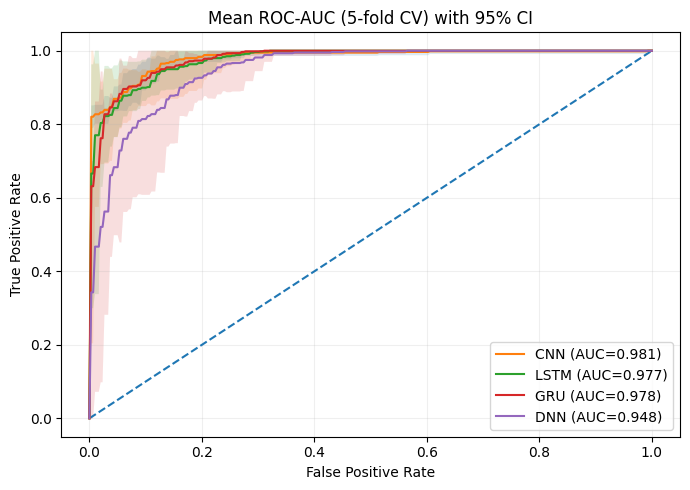

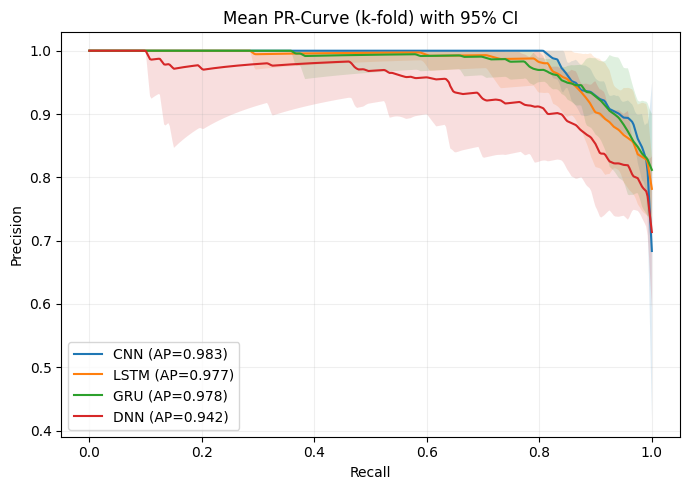

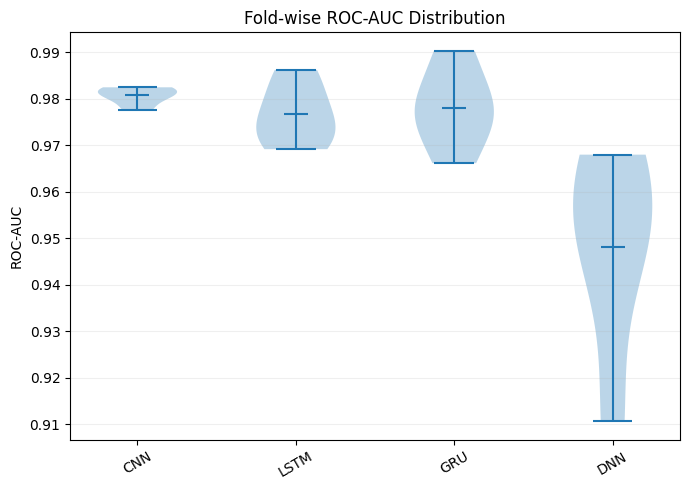

In [15]:
# -------------------------------------------------------------------
# Purpose: draw cross-validation curves and AUC-distribution plots from saved OOF probabilities.
# Ensure preds_dir points to the directory created during stacking.
# -------------------------------------------------------------------
# ==============================
# CONFIG (MUST match training)
# ==============================
N_SPLITS = 5
preds_dir = "stack_fold_preds"

models = ["CNN", "LSTM", "GRU", "DNN"]
y_true = np.load(os.path.join(preds_dir, "y_train.npy")).astype(int)

# Recreate same CV split
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_indices = list(skf.split(np.arange(len(y_true)), y_true))

# ==============================
# Display plots
# ==============================
plot_mean_roc(models, title="Mean ROC-AUC (5-fold CV) with 95% CI")
plot_mean_pr_fixed(models, title="Mean PR-Curve (5-fold) with 95% CI")
plot_violin_auc(models,title="Fold-wise ROC-AUC Distribution")


## 9. Internal independent test metrics

This section combines the internal-test metrics of all individual base learners, the blending ensemble, and the stacking ensemble.

The displayed table is suitable for manuscript or GitHub reporting because it includes threshold-based metrics, threshold-independent metrics, and calibration through the Brier score.


In [16]:
# -------------------------------------------------------------------
# Purpose: assemble the final internal independent test table for base learners and ensembles.
# This table is the main performance summary for the simplified notebook.
# -------------------------------------------------------------------
# Build internal test table
rows_int = {name: test_metrics_int[name] for name in base_learner_names}
rows_int["Blending"] = blend_ensemble_metrics_int
rows_int["Stacking"] = stack_int_metrics
res_int = pd.DataFrame(rows_int).T

paper_cols = ["ACC","Sn","Sp","F1","MCC","ROC-AUC","PR-AUC","Brier"]

print("=== Internal Holdout Test (Main) ===")
display(res_int[paper_cols].sort_values(by=paper_cols[0], ascending=False))



=== Internal Holdout Test (Main) ===


,ACC,Sn,Sp,F1,MCC,ROC-AUC,PR-AUC,Brier
CNN,0.969925,0.939394,1.000000,0.968750,0.941526,0.990954,0.991894,0.035994
Stacking,0.962406,0.924242,1.000000,0.960630,0.927394,0.991859,0.992593,0.034076
Blending,0.954887,0.909091,1.000000,0.952381,0.913439,0.990502,0.991404,0.041832
GRU,0.947368,0.909091,0.985075,0.944882,0.897214,0.987110,0.988239,0.052960
DNN,0.917293,0.893939,0.940299,0.914729,0.835372,0.964270,0.966690,0.075978
LSTM,0.909774,0.848485,0.970149,0.903226,0.825381,0.952962,0.961887,0.082238


### 9.1 Internal-test ROC and PR curves

The final cell plots ROC and precision-recall curves for all available internal-test probability outputs stored in `proba_int`. These figures help visually compare base learners, blending, and stacking on the held-out internal test set.


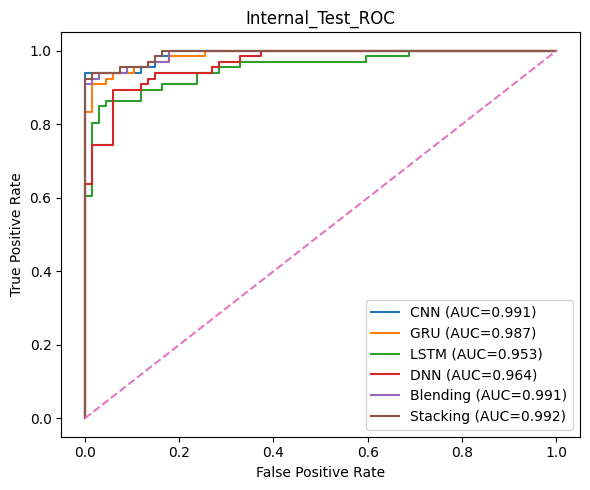

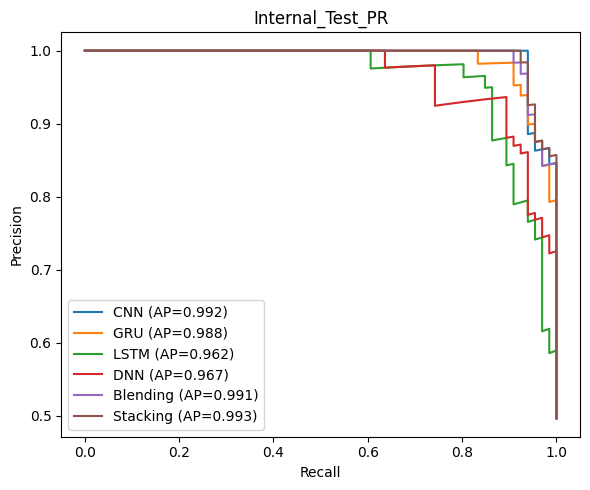

In [17]:
# -------------------------------------------------------------------
# Purpose: plot ROC and PR curves for internal independent test predictions.
# The curves are saved as SVG files and displayed inline.
# -------------------------------------------------------------------
# ---- Plots: Internal test ----
plot_roc_curves(y_test, proba_int, title="Internal_Test_ROC")
plot_pr_curves(y_test, proba_int, title="Internal_Test_PR")
